In [ ]:
# PHASE - 1
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# ── Load stations metadata ────────────────────────────
stations = pd.read_csv("stations.csv")
print("✅ Stations loaded:", stations.shape)

# ── Only load essential columns ───────────────────────
# This massively reduces memory usage
use_cols = ['pm2.5', 'pm10', 'no2', 'so2', 'co', 'ozone', 'nh3', 'timestamp']

# ── Load ALL 546 station CSV files ────────────────────
all_files = glob.glob("**/*.csv", recursive=True)
all_files = [f for f in all_files if "stations.csv" not in f]
print(f"📁 Total station files found: {len(all_files)}")

# ── Combine all files ─────────────────────────────────
dfs = []
skipped = 0

for filepath in all_files:
    try:
        # Load only needed columns with optimized dtypes
        temp = pd.read_csv(
            filepath,
            usecols=use_cols,
            dtype={
                'pm2.5' : 'float32',
                'pm10'  : 'float32',
                'no2'   : 'float32',
                'so2'   : 'float32',
                'co'    : 'float32',
                'ozone' : 'float32',
                'nh3'   : 'float32',
            }
        )

        # Parse timestamp and resample to DAILY averages
        temp['timestamp']    = pd.to_datetime(temp['timestamp'], errors='coerce')
        temp                 = temp.dropna(subset=['timestamp'])
        temp                 = temp.set_index('timestamp')
        temp                 = temp.resample('D').mean()  # daily average
        temp                 = temp.reset_index()

        # Add station info
        station_code         = os.path.splitext(os.path.basename(filepath))[0]
        state                = os.path.basename(os.path.dirname(filepath)).replace("_", " ")
        temp['station_code'] = station_code
        temp['state']        = state

        dfs.append(temp)

    except Exception as e:
        skipped += 1

df_raw = pd.concat(dfs, ignore_index=True)
print(f"\n✅ All files combined!")
print(f"Files skipped due to errors : {skipped}")
print(f"Total rows (daily)          : {df_raw.shape[0]:,}")
print(f"Total columns               : {df_raw.shape[1]}")

# ── Merge with stations metadata ──────────────────────
df = df_raw.merge(stations, on='station_code', how='left')
print(f"\n✅ Merged with stations!")
print(f"Final shape : {df.shape}")
print(f"\nSample:")
print(df.head())

✅ Stations loaded: (553, 11)
📁 Total station files found: 546

✅ All files combined!
Files skipped due to errors : 63
Total rows (daily)          : 733,808
Total columns               : 10

✅ Merged with stations!
Final shape : (738097, 20)

Sample:
   timestamp      pm2.5        pm10        no2        so2        co  \
0 2017-11-24  72.074074  116.851852  19.825926  10.585185  0.100000   
1 2017-11-25  83.721519  127.126579  20.855696  16.187014  0.139873   
2 2017-11-26  79.290321  132.354843  27.440861  22.616484  0.139785   
3 2017-11-27  87.964287  132.107147  29.437500  33.283333  0.116071   
4 2017-11-28  65.400002  104.933334  27.620001  18.077778  0.106667   

        ozone        nh3 station_code           state     id       city  \
0  108.448151  12.985186         AP01  Andhra Pradesh  123.0  Amaravati   
1  128.493668  10.498734         AP01  Andhra Pradesh  123.0  Amaravati   
2  114.038704  10.217204         AP01  Andhra Pradesh  123.0  Amaravati   
3  111.130356  14.10363

In [ ]:
# PHASE - 2
# ── Rename timestamp to date ──────────────────────────
df.rename(columns={'timestamp': 'date'}, inplace=True)
df['date'] = pd.to_datetime(df['date'])

# ── Extract time features ─────────────────────────────
df['year']  = df['date'].dt.year
df['month'] = df['date'].dt.month
df['season'] = df['month'].map({
    12: 'Winter', 1: 'Winter',  2: 'Winter',
    3:  'Spring', 4: 'Spring',  5: 'Spring',
    6:  'Summer', 7: 'Summer',  8: 'Summer',
    9:  'Autumn', 10: 'Autumn', 11: 'Autumn'
})

# ── Define pollutants ─────────────────────────────────
pollutants = ['pm2.5', 'pm10', 'no2', 'so2', 'co', 'ozone', 'nh3']
pollutants = [p for p in pollutants if p in df.columns]

# ── Fill missing values with median ───────────────────
for col in pollutants:
    df[col] = df[col].fillna(df[col].median())

# ── Calculate AQI from PM2.5 ──────────────────────────
def calc_aqi(pm25):
    if pd.isna(pm25):   return None
    if pm25 <= 12:      return round((50/12) * pm25)
    elif pm25 <= 35.4:  return round(((100-51)/(35.4-12.1))  * (pm25-12.1)  + 51)
    elif pm25 <= 55.4:  return round(((150-101)/(55.4-35.5)) * (pm25-35.5)  + 101)
    elif pm25 <= 150.4: return round(((200-151)/(150.4-55.5))* (pm25-55.5)  + 151)
    elif pm25 <= 250.4: return round(((300-201)/(250.4-150.5))*(pm25-150.5) + 201)
    else:               return round(((500-301)/(500.4-250.5))*(pm25-250.5) + 301)

def aqi_bucket(val):
    if pd.isna(val):    return None
    if val <= 50:       return 'Good'
    elif val <= 100:    return 'Satisfactory'
    elif val <= 200:    return 'Moderate'
    elif val <= 300:    return 'Poor'
    elif val <= 400:    return 'Very Poor'
    else:               return 'Severe'

df['AQI']        = df['pm2.5'].apply(calc_aqi)
df['AQI_Bucket'] = df['AQI'].apply(aqi_bucket)

# ── Drop rows with no AQI ─────────────────────────────
before = len(df)
df     = df.dropna(subset=['AQI'])
print(f"Rows removed (no AQI): {before - len(df):,}")

# ── Final summary ─────────────────────────────────────
print(f"\n✅ Cleaning Done!")
print(f"Final shape      : {df.shape}")
print(f"Date range       : {df['date'].min()} → {df['date'].max()}")
print(f"States covered   : {df['state'].nunique()}")
print(f"Stations covered : {df['station_code'].nunique()}")
print(f"Cities covered   : {df['city'].nunique()}")
print(f"\nAQI Bucket distribution:")
print(df['AQI_Bucket'].value_counts())

Rows removed (no AQI): 0

✅ Cleaning Done!
Final shape      : (738097, 25)
Date range       : 2009-01-01 00:00:00 → 2024-12-31 00:00:00
States covered   : 20
Stations covered : 483
Cities covered   : 240

AQI Bucket distribution:
AQI_Bucket
Moderate        424491
Satisfactory    224599
Good             46152
Poor             31670
Very Poor         8922
Severe            2263
Name: count, dtype: int64


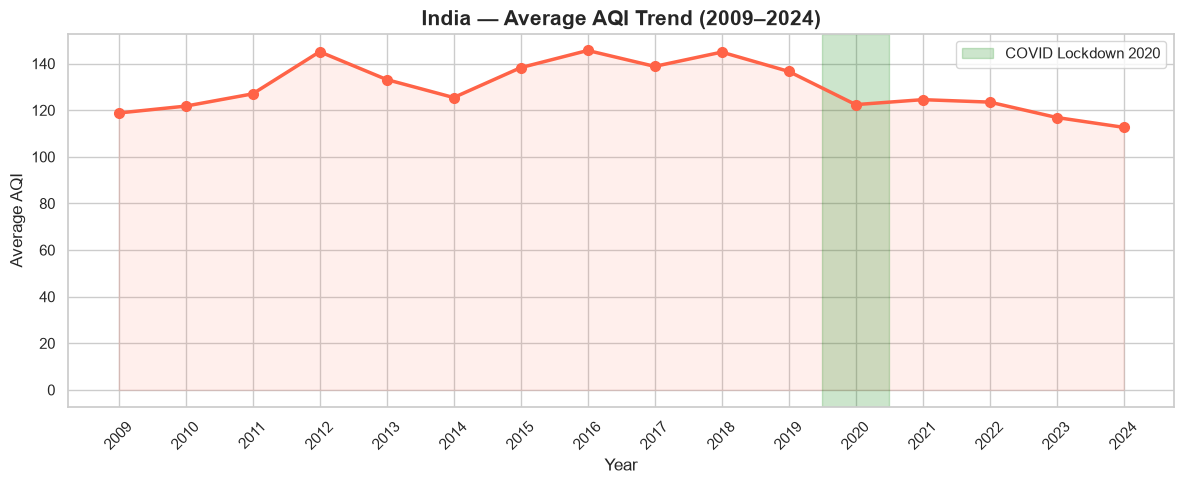

C:\Users\piyus\AppData\Local\Temp\ipykernel_17084\487962245.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='year', y='AQI', palette='RdYlGn_r')


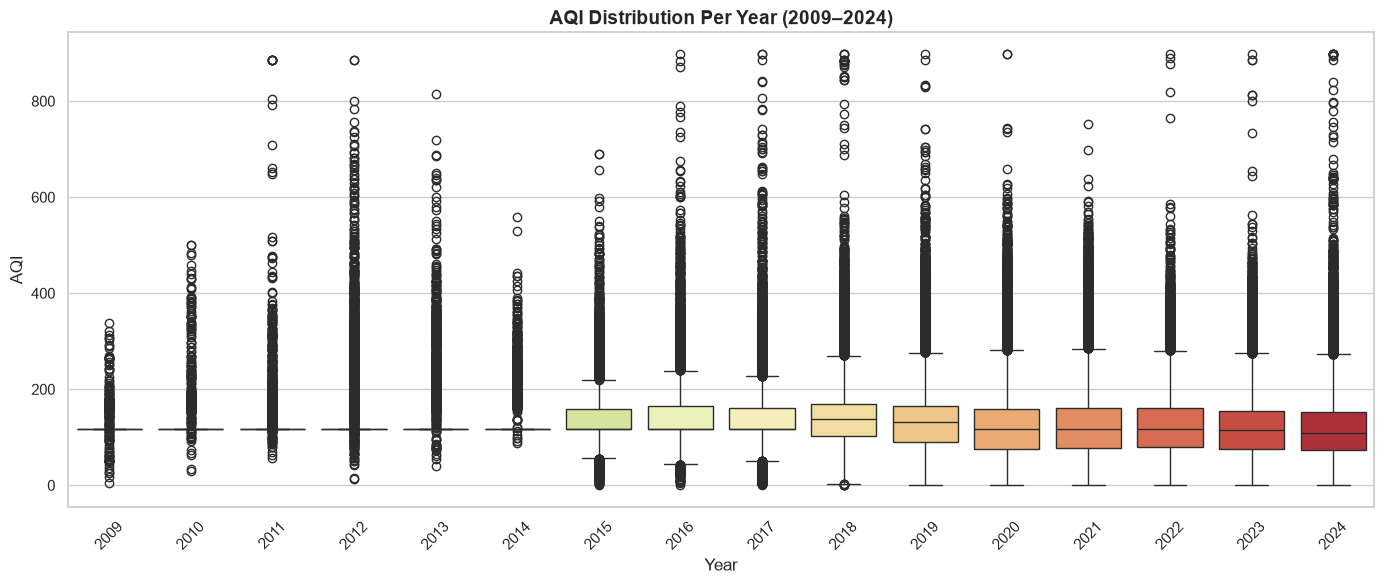

In [3]:
# PHASE - 3

# ── Chart 1: Yearly AQI Trend ─────────────────────────
yearly = df.groupby('year')['AQI'].mean()

plt.figure(figsize=(12, 5))
plt.plot(yearly.index, yearly.values, marker='o',
         color='tomato', linewidth=2.5, markersize=7)
plt.fill_between(yearly.index, yearly.values, alpha=0.1, color='tomato')
plt.axvspan(2019.5, 2020.5, color='green', alpha=0.2, label='COVID Lockdown 2020')
plt.title("India — Average AQI Trend (2009–2024)", fontsize=15, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Average AQI")
plt.xticks(yearly.index, rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("phase3_national_trend.png", dpi=150)
plt.show()

# ── Chart 2: Year-wise AQI Box Plot ──────────────────
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='year', y='AQI', palette='RdYlGn_r')
plt.title("AQI Distribution Per Year (2009–2024)", fontsize=14, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("AQI")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("phase3_yearly_boxplot.png", dpi=150)
plt.show()

C:\Users\piyus\AppData\Local\Temp\ipykernel_17084\1578019714.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_aqi.values, y=state_aqi.index, palette="Reds_r")


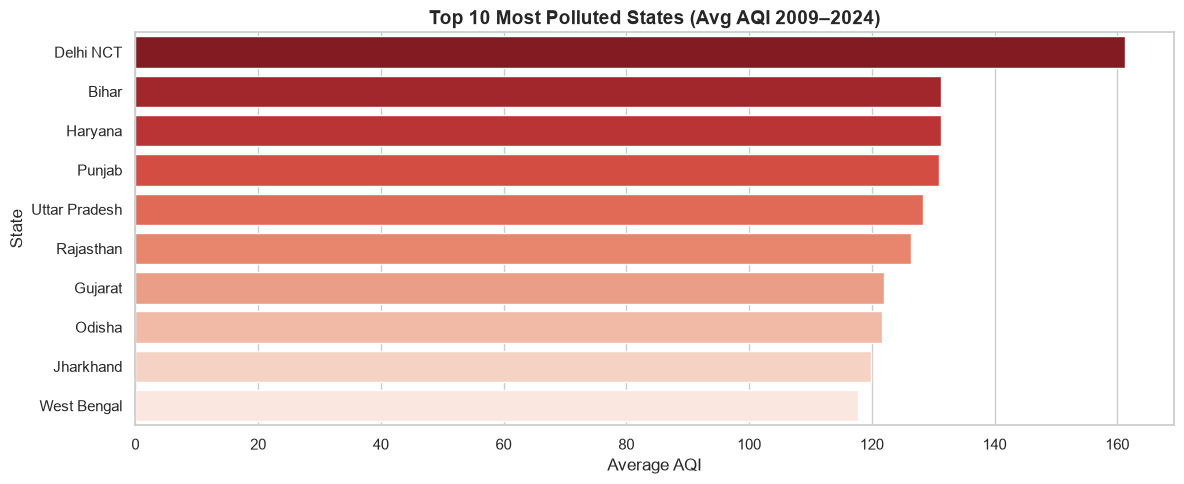

C:\Users\piyus\AppData\Local\Temp\ipykernel_17084\1578019714.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_aqi.values, y=city_aqi.index, palette="Oranges_r")


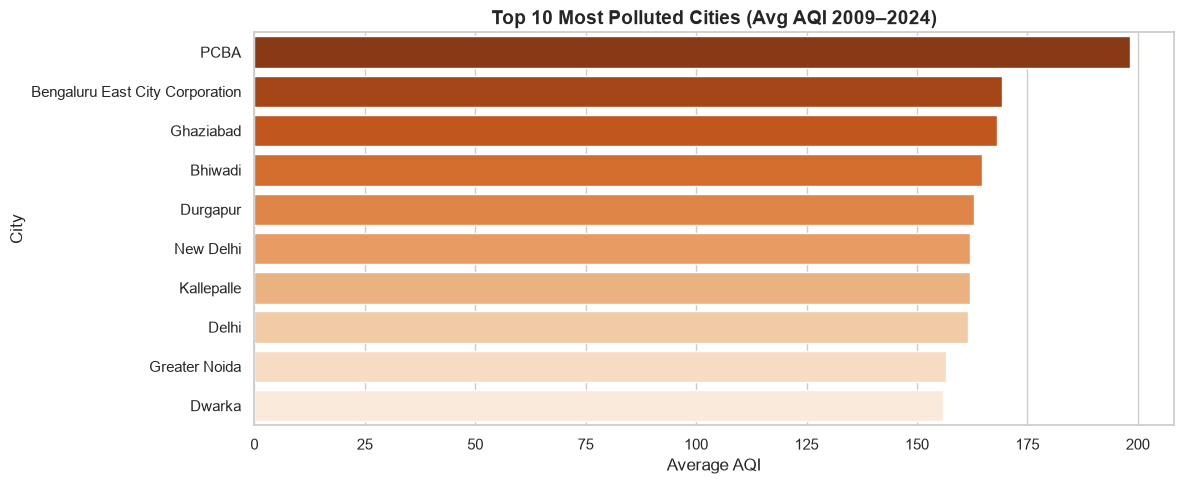

C:\Users\piyus\AppData\Local\Temp\ipykernel_17084\1578019714.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=clean_cities.values, y=clean_cities.index, palette="Greens_r")


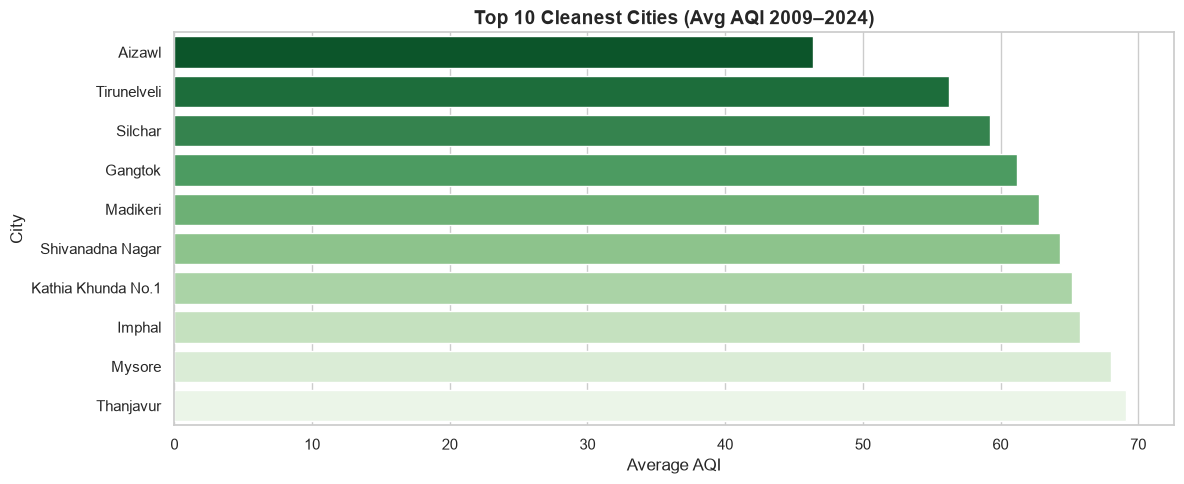

C:\Users\piyus\AppData\Local\Temp\ipykernel_17084\1578019714.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=all_states.values, y=all_states.index, palette="RdYlGn_r")


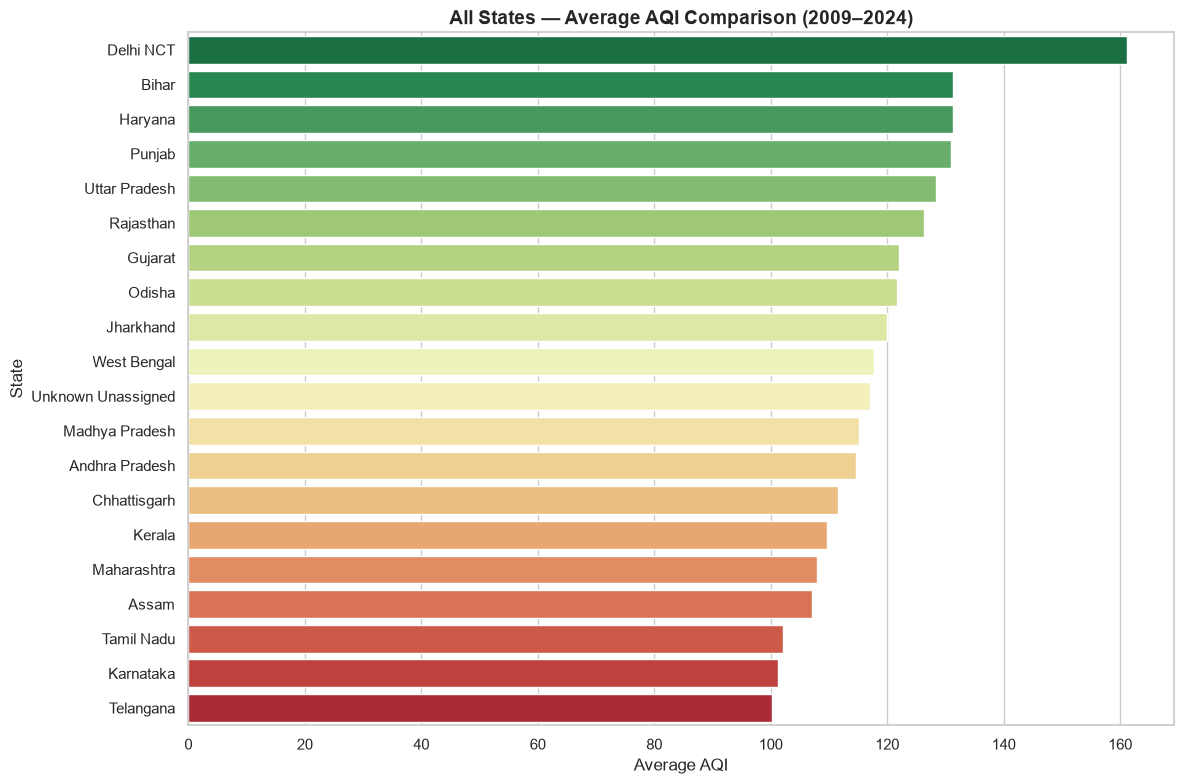

In [4]:
# PHASE - 4

# ── Chart 3: Top 10 Most Polluted States ─────────────
state_aqi = df.groupby('state')['AQI'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=state_aqi.values, y=state_aqi.index, palette="Reds_r")
plt.title("Top 10 Most Polluted States (Avg AQI 2009–2024)",
          fontsize=14, fontweight='bold')
plt.xlabel("Average AQI")
plt.ylabel("State")
plt.tight_layout()
plt.savefig("phase4_top_states.png", dpi=150)
plt.show()

# ── Chart 4: Top 10 Most Polluted Cities ─────────────
city_aqi = df.groupby('city')['AQI'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=city_aqi.values, y=city_aqi.index, palette="Oranges_r")
plt.title("Top 10 Most Polluted Cities (Avg AQI 2009–2024)",
          fontsize=14, fontweight='bold')
plt.xlabel("Average AQI")
plt.ylabel("City")
plt.tight_layout()
plt.savefig("phase4_top_cities.png", dpi=150)
plt.show()

# ── Chart 5: Top 10 Cleanest Cities ──────────────────
clean_cities = df.groupby('city')['AQI'].mean().sort_values().head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=clean_cities.values, y=clean_cities.index, palette="Greens_r")
plt.title("Top 10 Cleanest Cities (Avg AQI 2009–2024)",
          fontsize=14, fontweight='bold')
plt.xlabel("Average AQI")
plt.ylabel("City")
plt.tight_layout()
plt.savefig("phase4_cleanest_cities.png", dpi=150)
plt.show()

# ── Chart 6: All States Comparison ───────────────────
all_states = df.groupby('state')['AQI'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=all_states.values, y=all_states.index, palette="RdYlGn_r")
plt.title("All States — Average AQI Comparison (2009–2024)",
          fontsize=14, fontweight='bold')
plt.xlabel("Average AQI")
plt.ylabel("State")
plt.tight_layout()
plt.savefig("phase4_all_states.png", dpi=150)
plt.show()

C:\Users\piyus\AppData\Local\Temp\ipykernel_17084\1849671550.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AQI', y='label', data=top_stations, palette="YlOrRd")


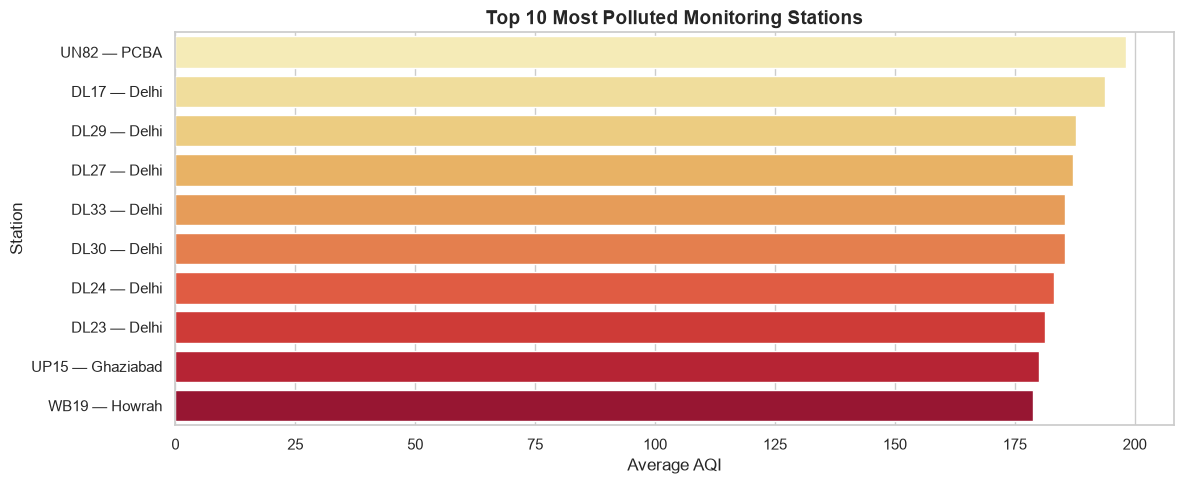

C:\Users\piyus\AppData\Local\Temp\ipykernel_17084\1849671550.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AQI', y='label', data=delhi_plot, palette="Reds_r")


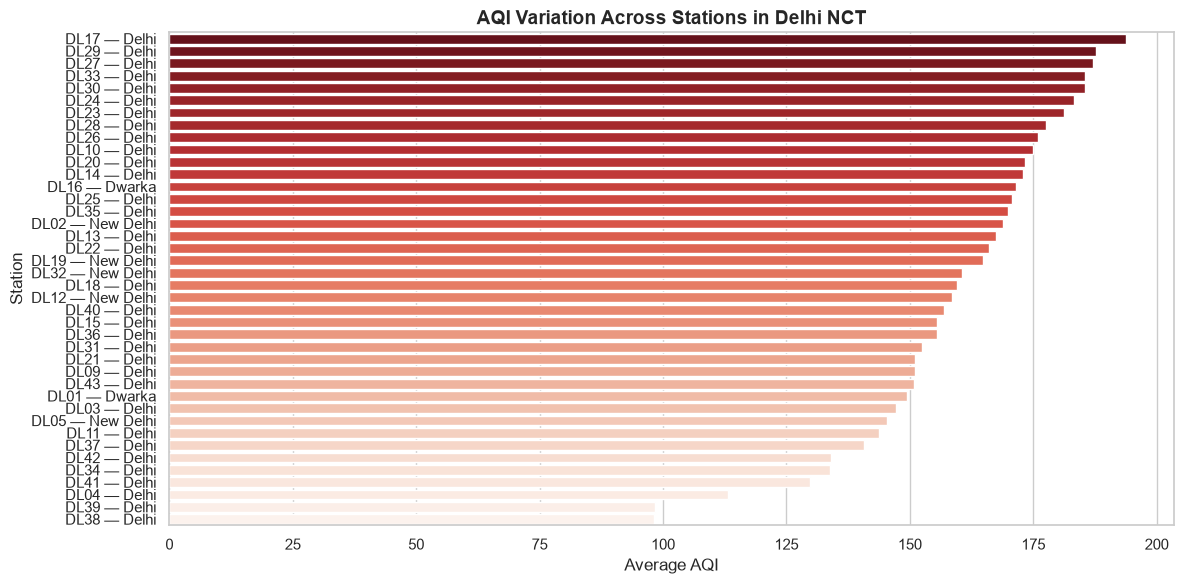

C:\Users\piyus\AppData\Local\Temp\ipykernel_17084\1849671550.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AQI', y='label', data=punjab_plot, palette="Oranges_r")


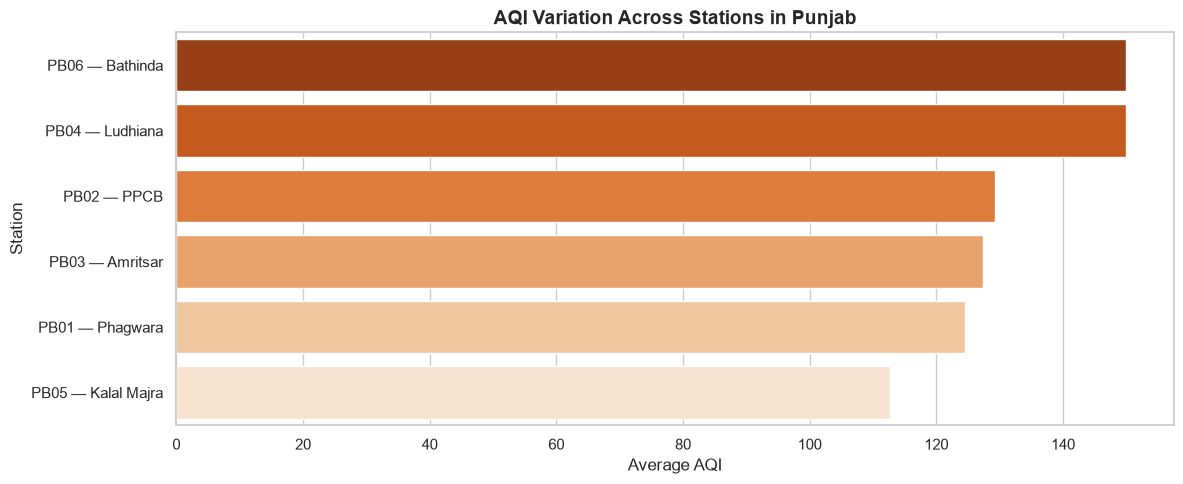

In [5]:
# PHASE - 5 

# ── Chart 7: Top 10 Most Polluted Stations ───────────
station_aqi = df.groupby('station_code')['AQI'].mean().sort_values(ascending=False).head(10)

# Merge with station names for better labels
station_labels = df[['station_code','city','state']].drop_duplicates()
top_stations   = station_aqi.reset_index().merge(station_labels, on='station_code')
top_stations['label'] = top_stations['station_code'] + ' — ' + top_stations['city']

plt.figure(figsize=(12, 5))
sns.barplot(x='AQI', y='label', data=top_stations, palette="YlOrRd")
plt.title("Top 10 Most Polluted Monitoring Stations",
          fontsize=14, fontweight='bold')
plt.xlabel("Average AQI")
plt.ylabel("Station")
plt.tight_layout()
plt.savefig("phase5_top_stations.png", dpi=150)
plt.show()

# ── Chart 8: AQI variation across stations in Delhi ──
delhi_df       = df[df['state'] == 'Delhi NCT']
delhi_stations = delhi_df.groupby('station_code')['AQI'].mean().sort_values(ascending=False)
delhi_labels   = df[['station_code','city']].drop_duplicates()
delhi_plot     = delhi_stations.reset_index().merge(delhi_labels, on='station_code')
delhi_plot['label'] = delhi_plot['station_code'] + ' — ' + delhi_plot['city']

plt.figure(figsize=(12, 6))
sns.barplot(x='AQI', y='label', data=delhi_plot, palette="Reds_r")
plt.title("AQI Variation Across Stations in Delhi NCT",
          fontsize=14, fontweight='bold')
plt.xlabel("Average AQI")
plt.ylabel("Station")
plt.tight_layout()
plt.savefig("phase5_delhi_stations.png", dpi=150)
plt.show()

# ── Chart 9: AQI variation across stations in Punjab ──
punjab_df       = df[df['state'] == 'Punjab']
punjab_stations = punjab_df.groupby('station_code')['AQI'].mean().sort_values(ascending=False)
punjab_labels   = df[['station_code','city']].drop_duplicates()
punjab_plot     = punjab_stations.reset_index().merge(punjab_labels, on='station_code')
punjab_plot['label'] = punjab_plot['station_code'] + ' — ' + punjab_plot['city']

plt.figure(figsize=(12, 5))
sns.barplot(x='AQI', y='label', data=punjab_plot, palette="Oranges_r")
plt.title("AQI Variation Across Stations in Punjab",
          fontsize=14, fontweight='bold')
plt.xlabel("Average AQI")
plt.ylabel("Station")
plt.tight_layout()
plt.savefig("phase5_punjab_stations.png", dpi=150)
plt.show()

C:\Users\piyus\AppData\Local\Temp\ipykernel_17084\3235564677.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=months_label, y=monthly.values, palette="coolwarm")


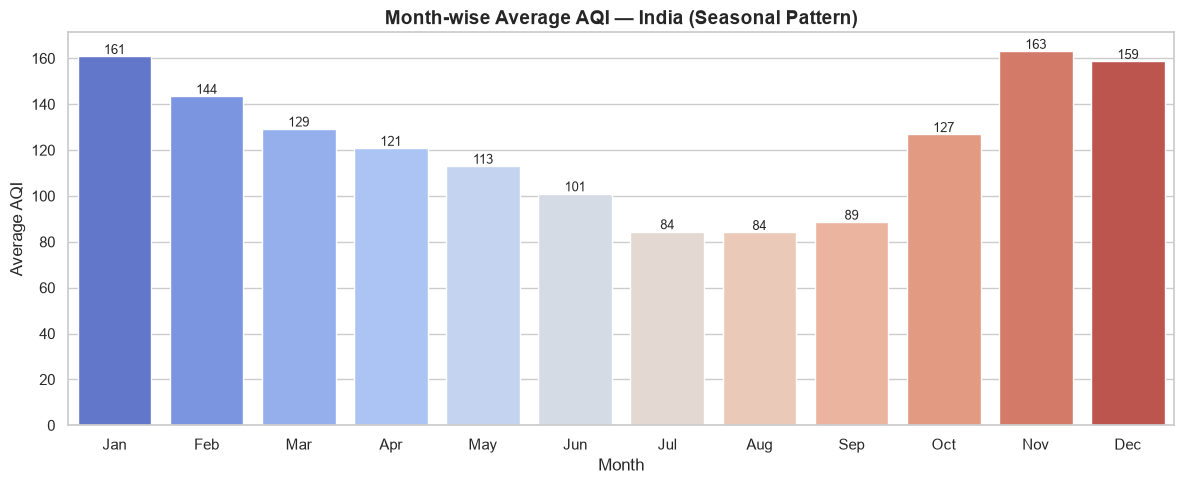

C:\Users\piyus\AppData\Local\Temp\ipykernel_17084\3235564677.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=season_aqi.index, y=season_aqi.values,


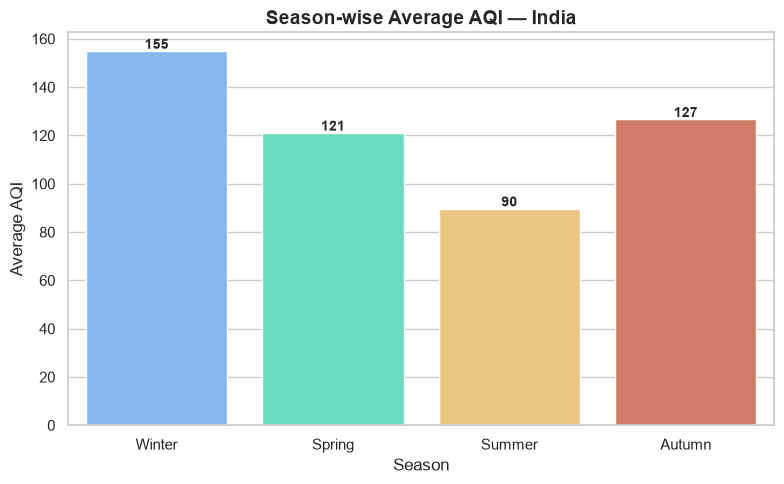

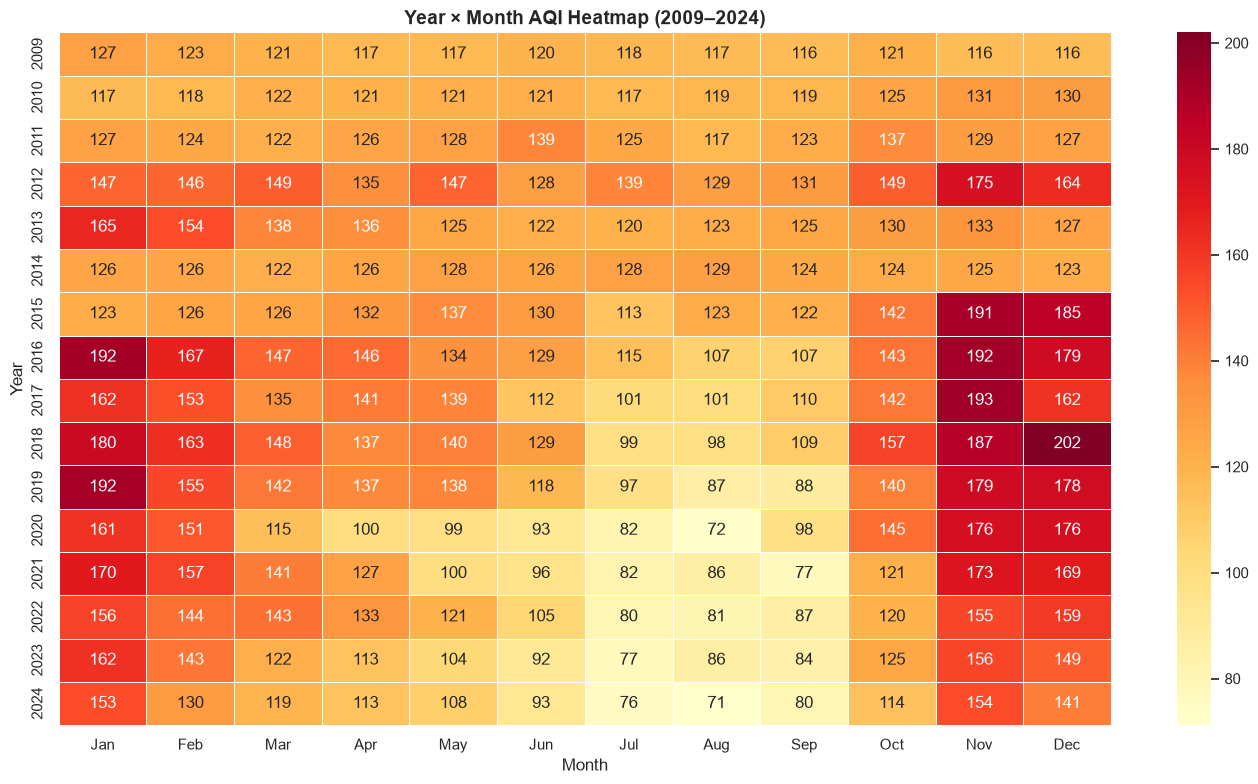

C:\Users\piyus\AppData\Local\Temp\ipykernel_17084\3235564677.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=months_label, y=punjab_monthly.values, palette="YlOrRd")


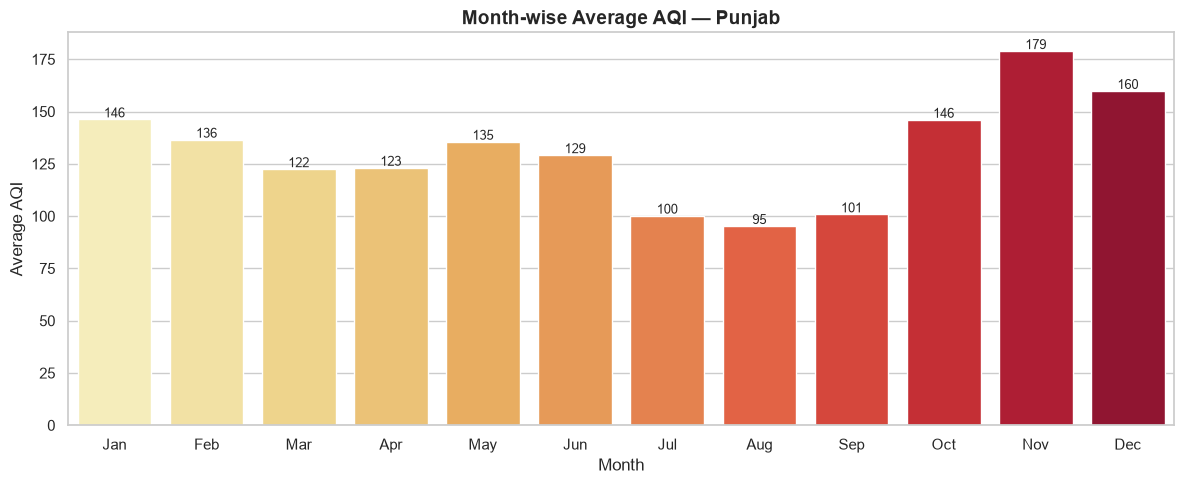

In [6]:
# PHASE - 6

months_label = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

# ── Chart 10: Month-wise AQI ──────────────────────────
monthly = df.groupby('month')['AQI'].mean()

plt.figure(figsize=(12, 5))
bars = sns.barplot(x=months_label, y=monthly.values, palette="coolwarm")
plt.title("Month-wise Average AQI — India (Seasonal Pattern)",
          fontsize=14, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Average AQI")
# Add value labels on bars
for i, v in enumerate(monthly.values):
    plt.text(i, v + 1, str(round(v)), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig("phase6_monthly.png", dpi=150)
plt.show()

# ── Chart 11: Season-wise AQI ─────────────────────────
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
season_aqi   = df.groupby('season')['AQI'].mean().reindex(season_order)

plt.figure(figsize=(8, 5))
sns.barplot(x=season_aqi.index, y=season_aqi.values,
            palette=["#74b9ff","#55efc4","#fdcb6e","#e17055"])
for i, v in enumerate(season_aqi.values):
    plt.text(i, v + 1, str(round(v)), ha='center', fontsize=10, fontweight='bold')
plt.title("Season-wise Average AQI — India",
          fontsize=14, fontweight='bold')
plt.xlabel("Season")
plt.ylabel("Average AQI")
plt.tight_layout()
plt.savefig("phase6_seasonal.png", dpi=150)
plt.show()

# ── Chart 12: Year × Month Heatmap ───────────────────
pivot = df.pivot_table(values='AQI', index='year',
                       columns='month', aggfunc='mean')
pivot.columns = months_label

plt.figure(figsize=(14, 8))
sns.heatmap(pivot, cmap='YlOrRd', annot=True,
            fmt=".0f", linewidths=0.5, linecolor='white')
plt.title("Year × Month AQI Heatmap (2009–2024)",
          fontsize=14, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.savefig("phase6_heatmap.png", dpi=150)
plt.show()

# ── Chart 13: Punjab Month-wise AQI ──────────────────
punjab_monthly = df[df['state'] == 'Punjab'].groupby('month')['AQI'].mean()

plt.figure(figsize=(12, 5))
sns.barplot(x=months_label, y=punjab_monthly.values, palette="YlOrRd")
for i, v in enumerate(punjab_monthly.values):
    plt.text(i, v + 1, str(round(v)), ha='center', fontsize=9)
plt.title("Month-wise Average AQI — Punjab",
          fontsize=14, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.tight_layout()
plt.savefig("phase6_punjab_monthly.png", dpi=150)
plt.show()

C:\Users\piyus\AppData\Local\Temp\ipykernel_17084\3172018811.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=avg_poll.index, y=avg_poll.values, palette="magma")


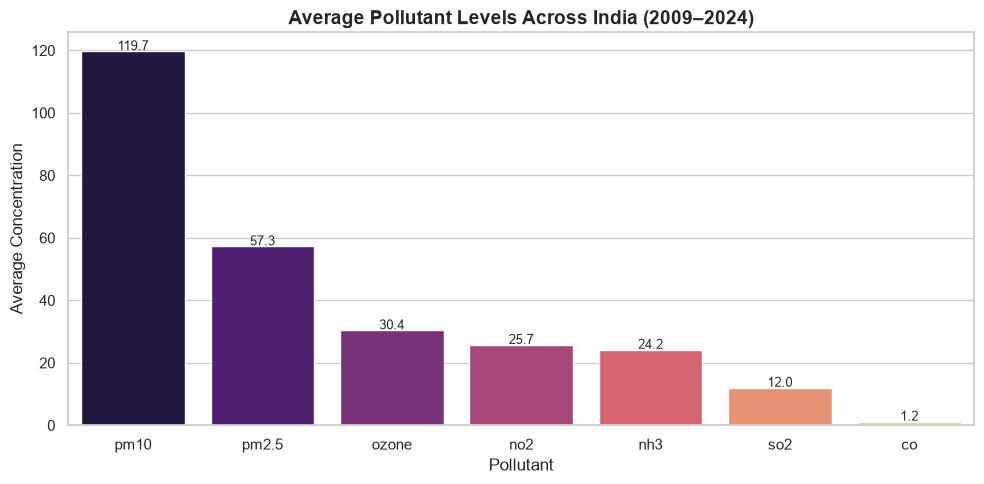

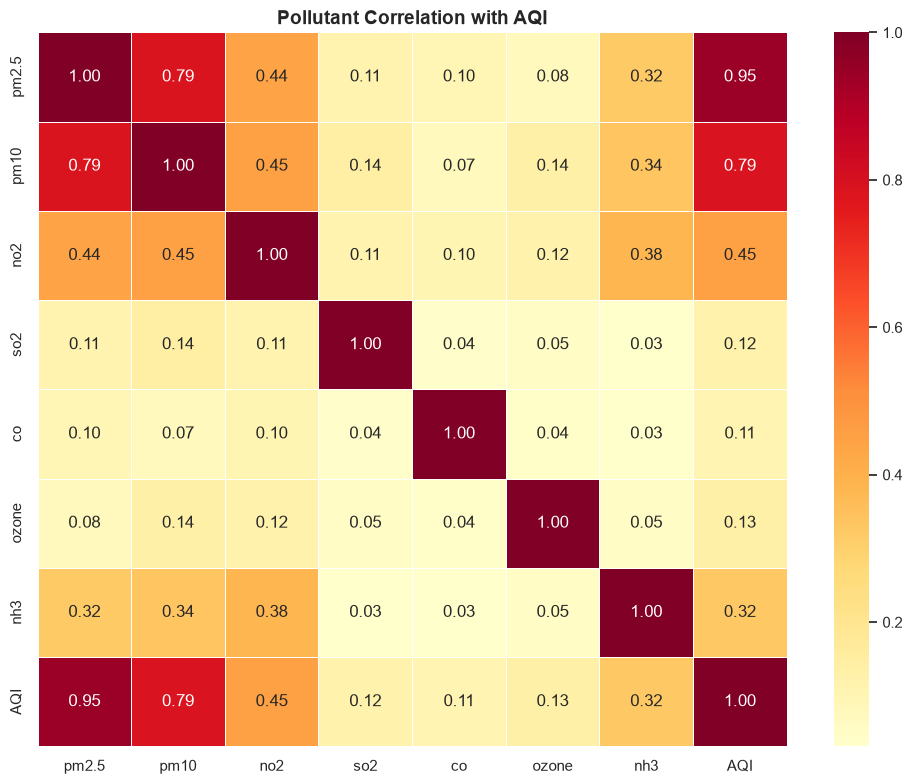

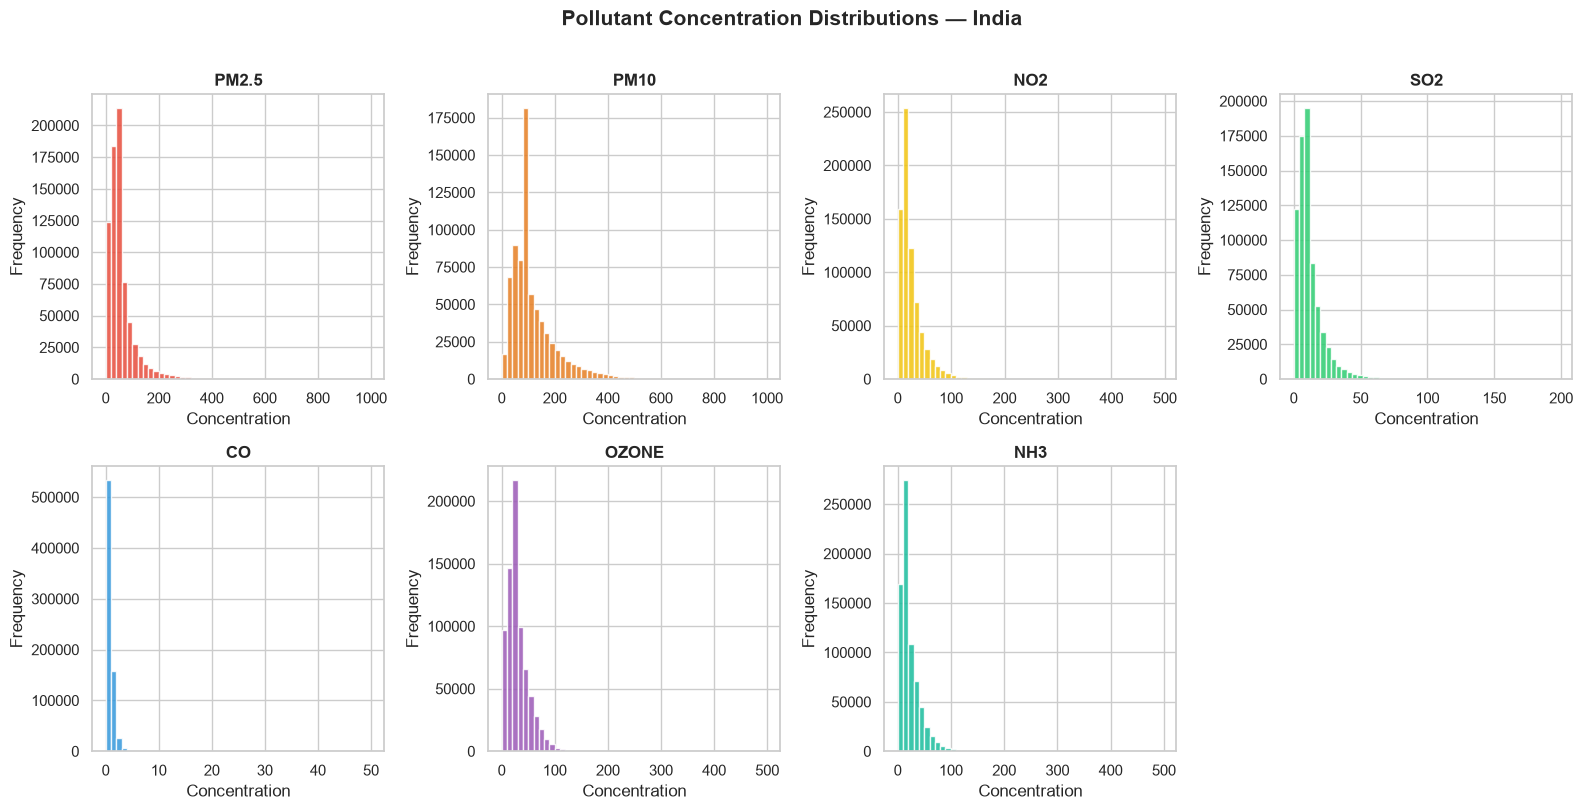

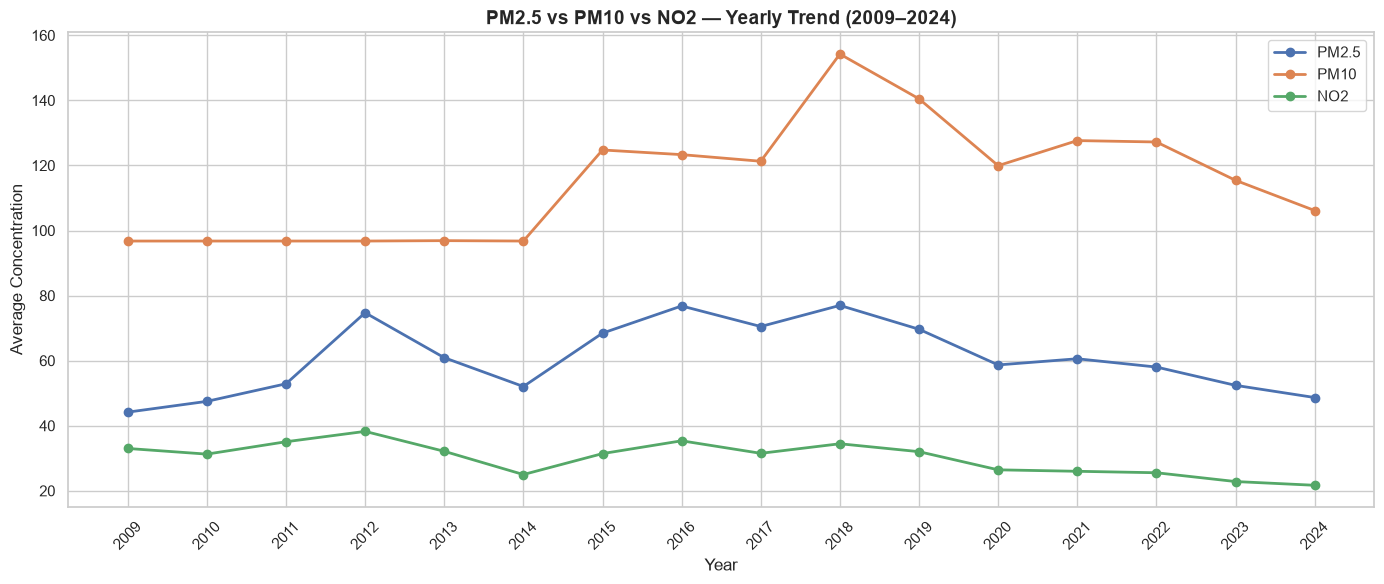

In [7]:
# PHASE - 7 

pollutants = ['pm2.5', 'pm10', 'no2', 'so2', 'co', 'ozone', 'nh3']
pollutants  = [p for p in pollutants if p in df.columns]

# ── Chart 14: Average Pollutant Levels ───────────────
avg_poll = df[pollutants].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bars = sns.barplot(x=avg_poll.index, y=avg_poll.values, palette="magma")
for i, v in enumerate(avg_poll.values):
    plt.text(i, v + 0.3, str(round(v, 1)), ha='center', fontsize=9)
plt.title("Average Pollutant Levels Across India (2009–2024)",
          fontsize=14, fontweight='bold')
plt.xlabel("Pollutant")
plt.ylabel("Average Concentration")
plt.tight_layout()
plt.savefig("phase7_avg_pollutants.png", dpi=150)
plt.show()

# ── Chart 15: Correlation Heatmap ────────────────────
plt.figure(figsize=(10, 8))
corr = df[pollutants + ['AQI']].corr()
sns.heatmap(corr, annot=True, cmap='YlOrRd',
            fmt=".2f", linewidths=0.5, linecolor='white')
plt.title("Pollutant Correlation with AQI",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("phase7_correlation.png", dpi=150)
plt.show()

# ── Chart 16: Pollutant Distributions ────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
colors = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db','#9b59b6','#1abc9c']
for i, col in enumerate(pollutants):
    axes[i].hist(df[col].dropna(), bins=50,
                 color=colors[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(f"{col.upper()}", fontweight='bold')
    axes[i].set_xlabel("Concentration")
    axes[i].set_ylabel("Frequency")
# Hide extra subplot if any
for j in range(len(pollutants), len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Pollutant Concentration Distributions — India",
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("phase7_distributions.png", dpi=150)
plt.show()

# ── Chart 17: Pollutant Trend Over Years ─────────────
yearly_poll = df.groupby('year')[pollutants].mean()

plt.figure(figsize=(14, 6))
for col in ['pm2.5', 'pm10', 'no2']:
    plt.plot(yearly_poll.index, yearly_poll[col],
             marker='o', linewidth=2, label=col.upper())
plt.title("PM2.5 vs PM10 vs NO2 — Yearly Trend (2009–2024)",
          fontsize=14, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Average Concentration")
plt.xticks(yearly_poll.index, rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("phase7_pollutant_trend.png", dpi=150)
plt.show()

C:\Users\piyus\AppData\Local\Temp\ipykernel_17084\1501508548.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=bucket_counts.index, y=bucket_counts.values,


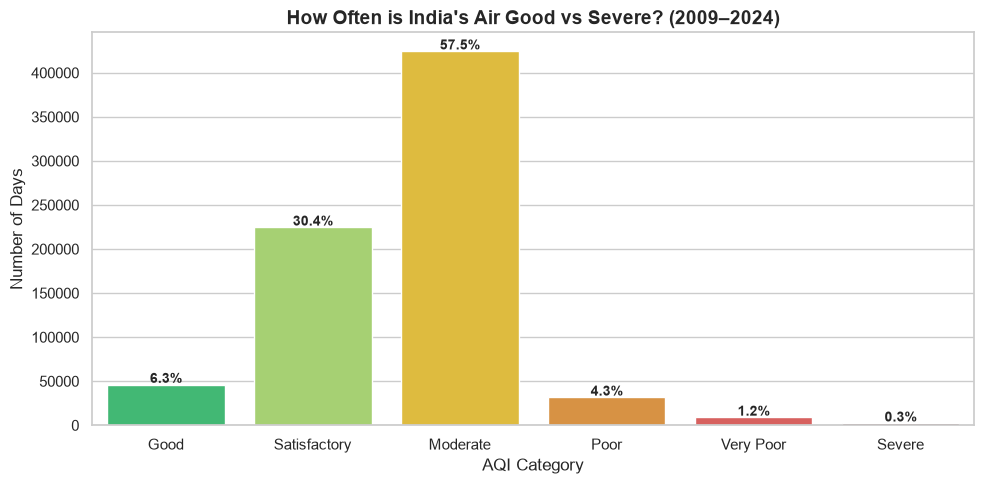

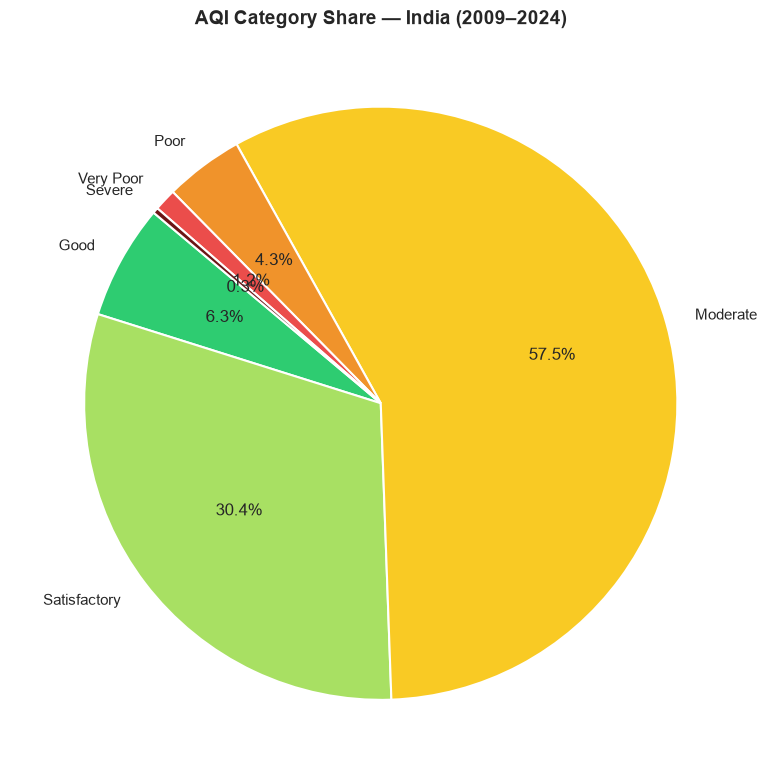

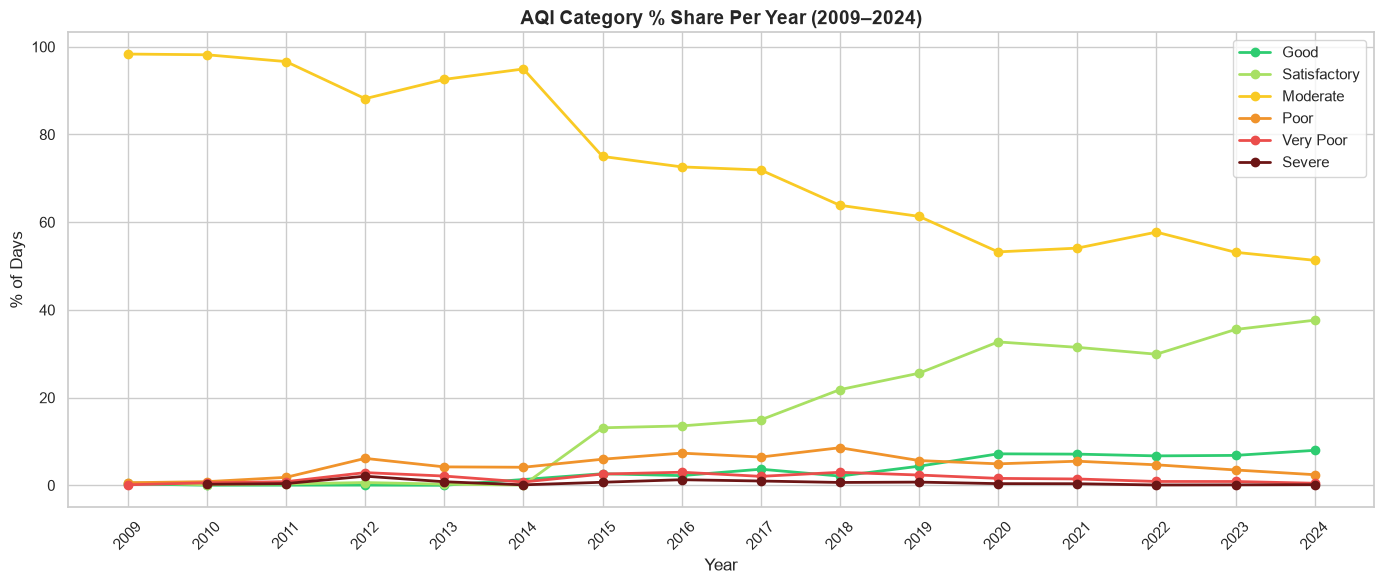

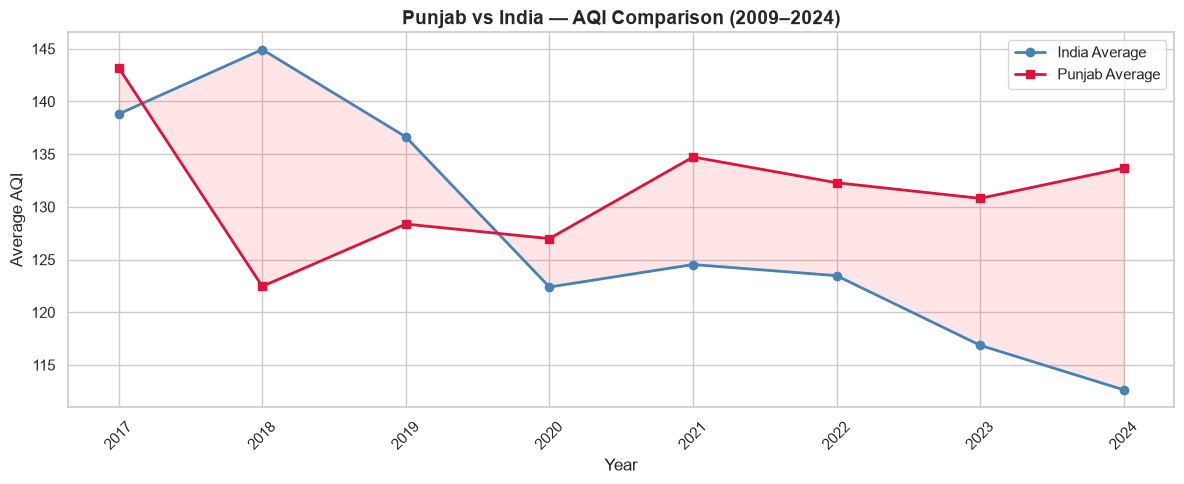

In [9]:
# PHASE - 8

# ── Chart 18: AQI Category Distribution ──────────────
bucket_order  = ['Good','Satisfactory','Moderate','Poor','Very Poor','Severe']
bucket_colors = ['#2ecc71','#a8e063','#f9ca24','#f0932b','#eb4d4b','#6c1515']
bucket_counts = df['AQI_Bucket'].value_counts().reindex(bucket_order).dropna()

plt.figure(figsize=(10, 5))
bars = sns.barplot(x=bucket_counts.index, y=bucket_counts.values,
                   palette=bucket_colors)
for i, v in enumerate(bucket_counts.values):
    pct = round(v / len(df) * 100, 1)
    plt.text(i, v + 2000, f"{pct}%", ha='center',
             fontsize=10, fontweight='bold')
plt.title("How Often is India's Air Good vs Severe? (2009–2024)",
          fontsize=14, fontweight='bold')
plt.xlabel("AQI Category")
plt.ylabel("Number of Days")
plt.tight_layout()
plt.savefig("phase8_aqi_buckets.png", dpi=150)
plt.show()

# ── Chart 19: Pie Chart ───────────────────────────────
plt.figure(figsize=(8, 8))
plt.pie(bucket_counts.values, labels=bucket_counts.index,
        colors=bucket_colors, autopct='%1.1f%%',
        startangle=140, wedgeprops={'edgecolor':'white','linewidth':1.5})
plt.title("AQI Category Share — India (2009–2024)",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("phase8_pie.png", dpi=150)
plt.show()

# ── Chart 20: AQI Category trend over years ──────────
bucket_year = (df.groupby(['year','AQI_Bucket'])
               .size()
               .reset_index(name='count'))
bucket_year['pct'] = (bucket_year
                      .groupby('year')['count']
                      .transform(lambda x: x / x.sum() * 100))

plt.figure(figsize=(14, 6))
for bucket, color in zip(bucket_order, bucket_colors):
    data = bucket_year[bucket_year['AQI_Bucket'] == bucket]
    plt.plot(data['year'], data['pct'], marker='o',
             label=bucket, color=color, linewidth=2)
plt.title("AQI Category % Share Per Year (2009–2024)",
          fontsize=14, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("% of Days")
plt.xticks(df['year'].unique(), rotation=45)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig("phase8_category_trend.png", dpi=150)
plt.show()

# ── Chart 21: Punjab vs India AQI comparison ─────────
india_yearly  = df.groupby('year')['AQI'].mean()
punjab_yearly = df[df['state']=='Punjab'].groupby('year')['AQI'].mean()

# ── Align both to common years only ──────────────────
common_years  = india_yearly.index.intersection(punjab_yearly.index)
india_yearly  = india_yearly[common_years]
punjab_yearly = punjab_yearly[common_years]

plt.figure(figsize=(12, 5))
plt.plot(common_years, india_yearly.values,
         marker='o', color='steelblue', linewidth=2,
         label='India Average')
plt.plot(common_years, punjab_yearly.values,
         marker='s', color='crimson', linewidth=2,
         label='Punjab Average')
plt.fill_between(common_years,
                 india_yearly.values,
                 punjab_yearly.values,
                 alpha=0.1, color='red')
plt.title("Punjab vs India — AQI Comparison (2009–2024)",
          fontsize=14, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Average AQI")
plt.xticks(common_years, rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("phase8_punjab_vs_india.png", dpi=150)
plt.show()